<a href="https://colab.research.google.com/github/krishnasai272/DeepLearning/blob/main/Experiment-16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

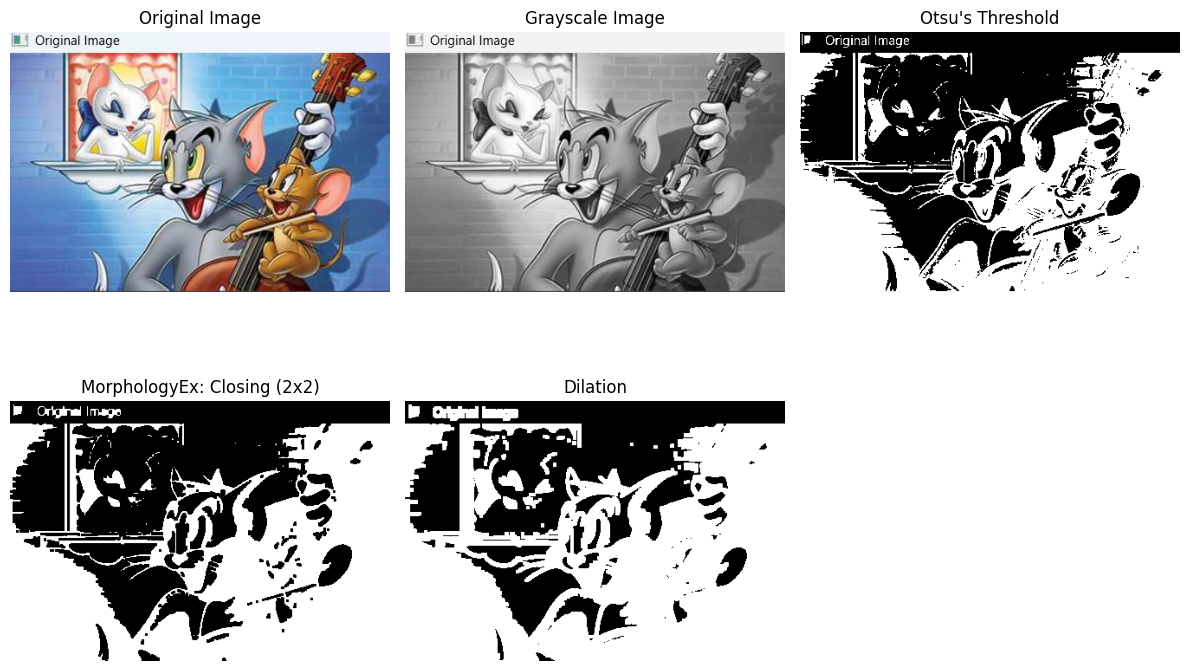

In [25]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Load the image directly from the current directory (upload your image to Colab first)
img_path = '/content/Screenshot 2025-07-02 100906.png'
img = cv2.imread(img_path)

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check if the file is uploaded to Colab.")
else:
    b, g, r = cv2.split(img)
    rgb_img = cv2.merge([r, g, b])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((2, 2), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    sure_bg = cv2.dilate(closing, kernel, iterations=3)

    plt.figure(figsize=(12, 8))
    plt.subplot(231); plt.imshow(rgb_img); plt.title("Original Image"); plt.axis('off')
    plt.subplot(232); plt.imshow(gray, 'gray'); plt.title("Grayscale Image"); plt.axis('off')
    plt.subplot(233); plt.imshow(thresh, 'gray'); plt.title("Otsu's Threshold"); plt.axis('off')
    plt.subplot(234); plt.imshow(closing, 'gray'); plt.title("MorphologyEx: Closing (2x2)"); plt.axis('off')
    plt.subplot(235); plt.imshow(sure_bg, 'gray'); plt.title("Dilation"); plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.imsave('dilation.png', sure_bg, cmap='gray')